# Notebook 03 — Tarea 3: Aprendizaje No Supervisado
**Objetivo:** identificar perfiles de estudiantes mediante PCA y K-Means.

**Contenido:**
1. Selección y justificación del subconjunto de variables
2. PCA — varianza explicada y biplot
3. K-Means — método del codo + silhouette
4. Clustering jerárquico como contraste
5. Caracterización de clusters (heatmap)
6. Visualización 2D en espacio PCA
7. Estabilidad (ARI entre métodos y semillas)
8. Relación clusters vs. situación académica real

## 0. Imports y configuración

In [1]:
import sys, os, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing  import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose        import ColumnTransformer
from sklearn.decomposition  import PCA
from sklearn.cluster        import KMeans, AgglomerativeClustering
from sklearn.metrics        import silhouette_score, adjusted_rand_score

from utils import load_data, set_plot_style, encode_binary_cols, RANDOM_STATE

os.makedirs("../outputs", exist_ok=True)
set_plot_style()

## 1. Selección de variables y preprocesado

**Criterio de selección:** incluimos variables que describen al estudiante *antes* del resultado final (perfil de entrada, contexto socioeconómico, rendimiento del 1.er semestre). Excluimos:
- Variables del 2.º semestre (resultados finales que sesgarían el clustering).
- `objetivo` (variable target de clasificación).
- Variables de muy alta cardinalidad (`nacionalidad`, `ocupacion_madre/padre`, `cualificacion_madre/padre`) que dificultarían la interpretación sin aportar estructura clara.

In [2]:
df = load_data("../rendimiento_estudiantes.csv")
df = encode_binary_cols(df)

VARS_CLUSTER = [
    # Perfil académico de entrada
    "nota_admision", "nota_cualificacion_previa", "edad_al_matricularse",
    # Situación socioeconómica
    "becado", "deudor", "matricula_al_dia", "desplazado",
    # Demográfico y tipo de asistencia
    "genero", "asistencia_diurna_vespertina",
    # Rendimiento 1.er semestre
    "asignaturas_1sem_matriculadas", "asignaturas_1sem_aprobadas",
    "nota_media_1sem", "asignaturas_1sem_sin_evaluacion",
    # Contexto macroeconómico
    "tasa_desempleo", "pib",
]

X_cl     = df[VARS_CLUSTER].copy()
objetivo = df["objetivo"]

cat_cl = X_cl.select_dtypes(include="object").columns.tolist()
num_cl = X_cl.select_dtypes(exclude="object").columns.tolist()
print(f"Variables seleccionadas: {len(VARS_CLUSTER)}")
print(f"  Numéricas ({len(num_cl)}): {num_cl}")
print(f"  Categóricas ({len(cat_cl)}): {cat_cl}")

Variables seleccionadas: 15
  Numéricas (15): ['nota_admision', 'nota_cualificacion_previa', 'edad_al_matricularse', 'becado', 'deudor', 'matricula_al_dia', 'desplazado', 'genero', 'asistencia_diurna_vespertina', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'tasa_desempleo', 'pib']
  Categóricas (0): []


In [9]:
prep_cl = ColumnTransformer([
    ("num", StandardScaler(), num_cl),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cl),
])
X_prep = prep_cl.fit_transform(X_cl)
print(f"Matriz preprocesada: {X_prep.shape}")

Matriz preprocesada: (4424, 15)


## 2. PCA — análisis de varianza explicada

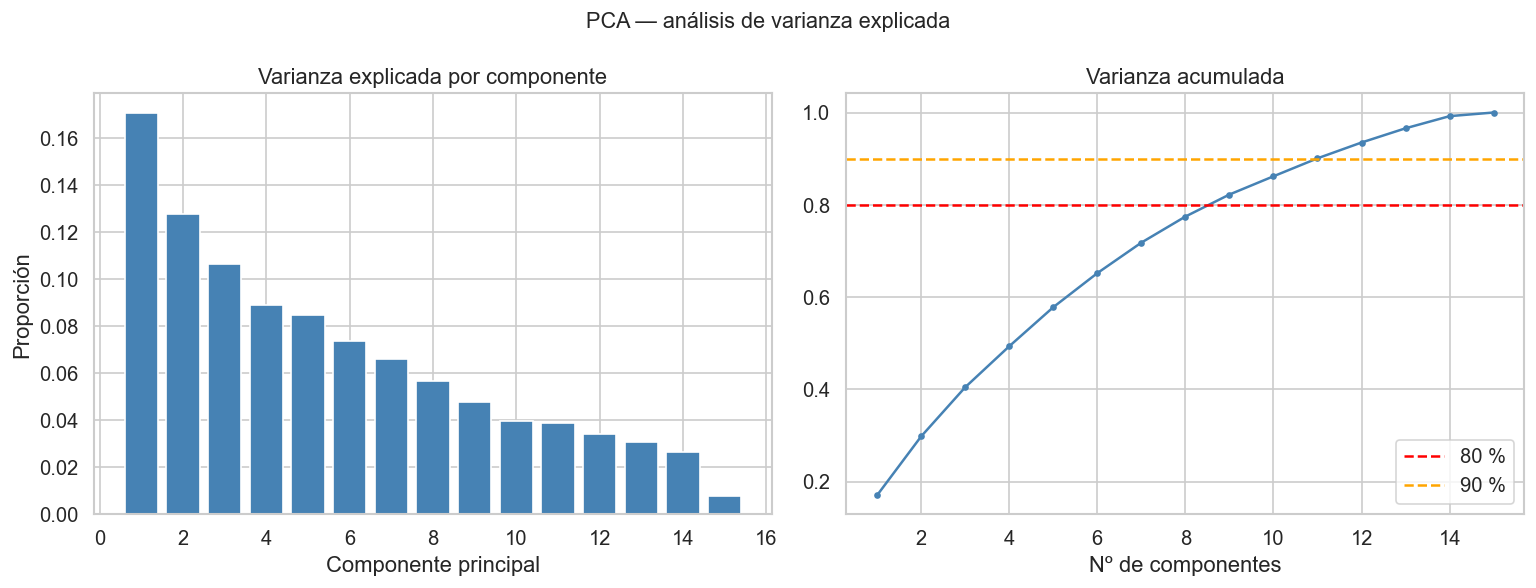

Componentes para 80 % de varianza: 9
Componentes para 90 % de varianza: 11


In [10]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_prep)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_,
            color="steelblue", edgecolor="white")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Proporción")

axes[1].plot(range(1, len(var_acum) + 1), var_acum, marker=".", color="steelblue")
axes[1].axhline(0.80, color="red",    linestyle="--", label="80 %")
axes[1].axhline(0.90, color="orange", linestyle="--", label="90 %")
axes[1].set_title("Varianza acumulada")
axes[1].set_xlabel("Nº de componentes")
axes[1].legend()

plt.suptitle("PCA — análisis de varianza explicada", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/03_pca_varianza.png", bbox_inches="tight")
plt.show()

n80 = int(np.argmax(var_acum >= 0.80)) + 1
n90 = int(np.argmax(var_acum >= 0.90)) + 1
print(f"Componentes para 80 % de varianza: {n80}")
print(f"Componentes para 90 % de varianza: {n90}")

## 3. Proyección 2D y biplot

Varianza explicada PC1+PC2: 29.79%


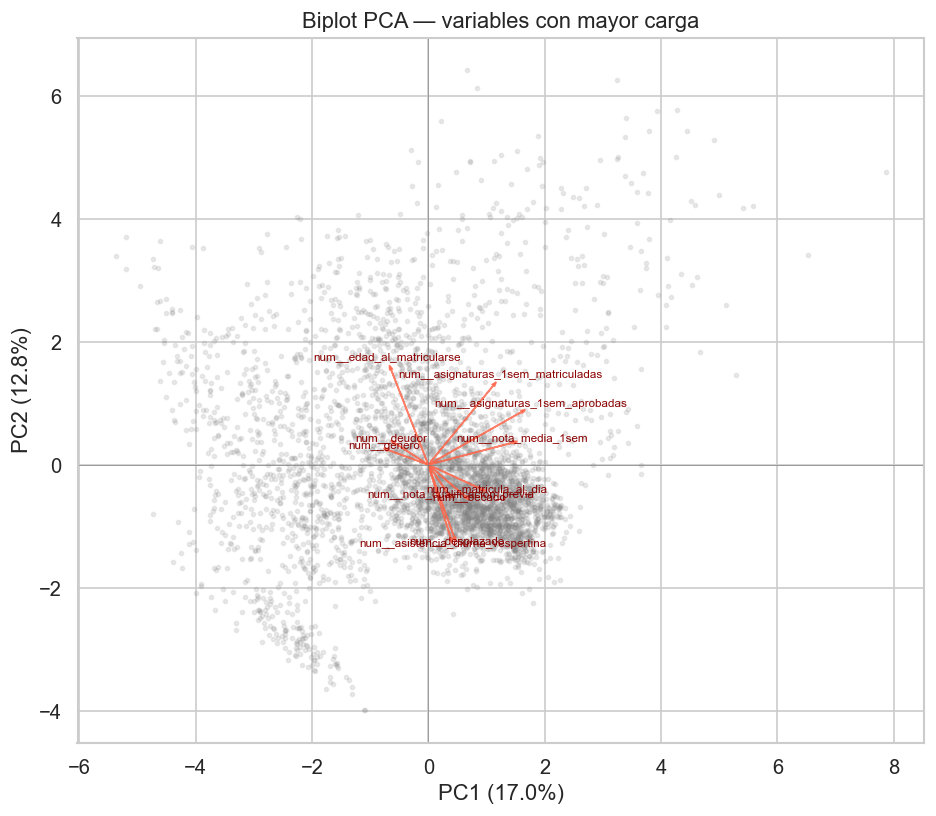

In [12]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca2.fit_transform(X_prep)
print(f"Varianza explicada PC1+PC2: {pca2.explained_variance_ratio_.sum():.2%}")

# Nombres de features tras el preprocesado
prep_cl.fit(X_cl)
feat_names = prep_cl.get_feature_names_out().tolist()

loadings = pd.DataFrame(pca2.components_.T, index=feat_names, columns=["PC1", "PC2"])
top_vars = list(
    set(loadings["PC1"].abs().nlargest(8).index) |
    set(loadings["PC2"].abs().nlargest(8).index)
)

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.15, s=6, color="gray")
for feat in top_vars:
    ax.arrow(0, 0,
             loadings.loc[feat, "PC1"] * 3,
             loadings.loc[feat, "PC2"] * 3,
             head_width=0.05, color="tomato", alpha=0.8)
    ax.text(loadings.loc[feat, "PC1"] * 3.3,
            loadings.loc[feat, "PC2"] * 3.3,
            feat, fontsize=7, ha="center", color="darkred")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.set_title("Biplot PCA — variables con mayor carga")
ax.axhline(0, color="gray", linewidth=0.4)
ax.axvline(0, color="gray", linewidth=0.4)
plt.tight_layout()
plt.savefig("../outputs/03_pca_biplot.png", bbox_inches="tight")
plt.show()

## 4. K-Means — selección del número óptimo de clusters

In [13]:
K_range     = range(2, 11)
inertias    = []
silhouettes = []

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_prep)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_prep, labels, sample_size=1500, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f"k={k:2d}: inercia={km.inertia_:9.0f} | silhouette={sil:.4f}")

k= 2: inercia=    58524 | silhouette=0.2150
k= 3: inercia=    53620 | silhouette=0.2206
k= 4: inercia=    50058 | silhouette=0.2244
k= 5: inercia=    46591 | silhouette=0.1279
k= 6: inercia=    43600 | silhouette=0.1361
k= 7: inercia=    41563 | silhouette=0.1343
k= 8: inercia=    39241 | silhouette=0.1310
k= 9: inercia=    37629 | silhouette=0.1366
k=10: inercia=    36453 | silhouette=0.1274


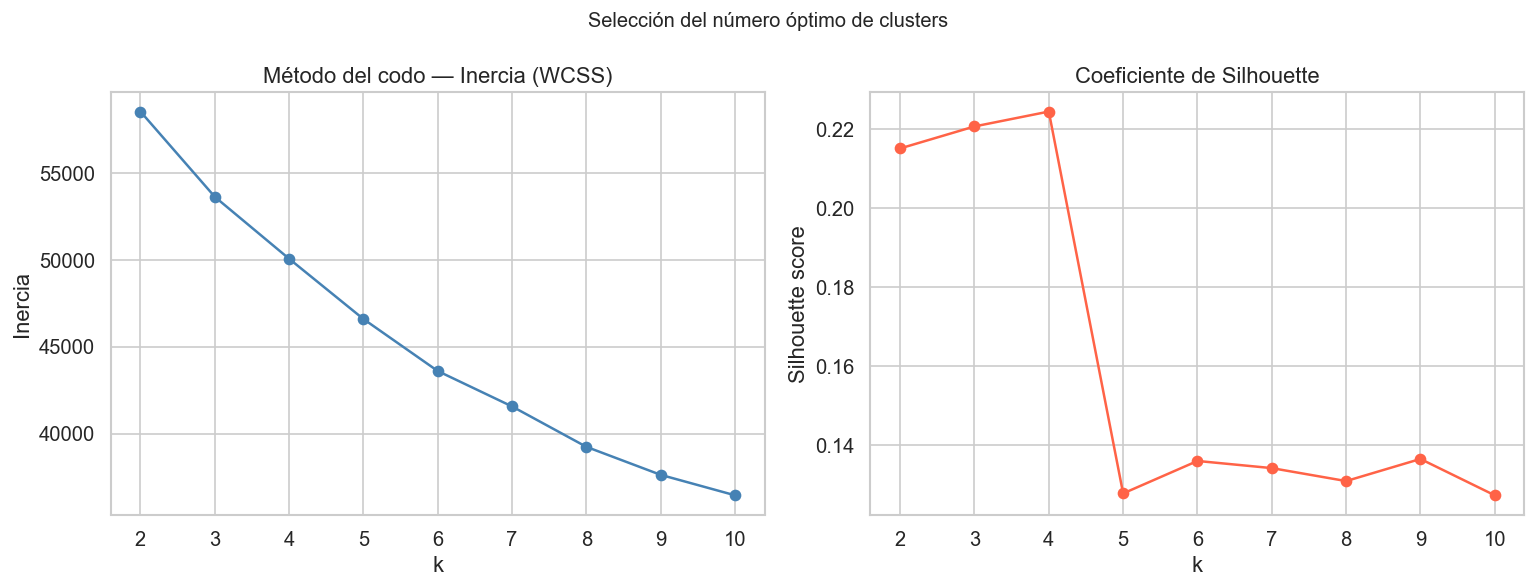


→ k óptimo por Silhouette: 4


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue")
axes[0].set_title("Método del codo — Inercia (WCSS)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(K_range), silhouettes, marker="o", color="tomato")
axes[1].set_title("Coeficiente de Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")

plt.suptitle("Selección del número óptimo de clusters", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/03_kmeans_seleccion_k.png", bbox_inches="tight")
plt.show()

k_optimo = list(K_range)[int(np.argmax(silhouettes))]
print(f"\n→ k óptimo por Silhouette: {k_optimo}")

## 5. K-Means final y caracterización de clusters

In [15]:
km_final       = KMeans(n_clusters=k_optimo, random_state=RANDOM_STATE, n_init=20)
cluster_labels = km_final.fit_predict(X_prep)
df["cluster"]  = cluster_labels

print(f"Distribución de clusters (k={k_optimo}):")
print(df["cluster"].value_counts().sort_index().to_string())

Distribución de clusters (k=4):
cluster
0     518
1    2120
2     957
3     829


In [16]:
vars_perfil = [
    "nota_admision", "nota_cualificacion_previa", "edad_al_matricularse",
    "nota_media_1sem", "asignaturas_1sem_aprobadas",
    "becado", "deudor", "matricula_al_dia",
]
perfil = df.groupby("cluster")[vars_perfil].mean().round(3)
print("Perfil medio por cluster:")
print(perfil.to_string())
perfil.to_csv("../outputs/03_perfil_clusters.csv")

Perfil medio por cluster:
         nota_admision  nota_cualificacion_previa  edad_al_matricularse  nota_media_1sem  asignaturas_1sem_aprobadas  becado  deudor  matricula_al_dia
cluster                                                                                                                                               
0              126.803                    130.244                35.166           10.284                       4.867   0.124   0.093             0.869
1              127.285                    132.814                21.359           12.759                       5.633   0.000   0.066             0.967
2              127.263                    133.794                19.866           12.972                       5.991   1.000   0.064             0.970
3              125.974                    132.217                24.627            2.757                       0.756   0.094   0.306             0.563


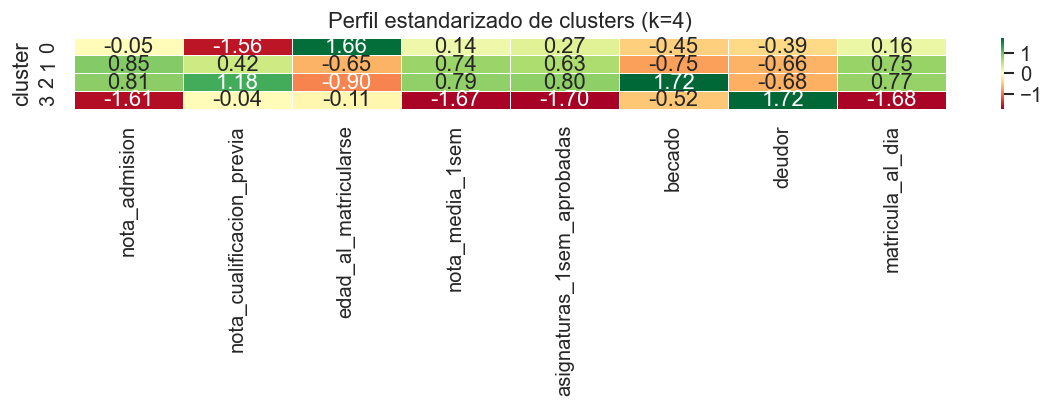

In [17]:
scaler_viz = StandardScaler()
perfil_std = pd.DataFrame(
    scaler_viz.fit_transform(perfil),
    index=perfil.index,
    columns=perfil.columns,
)
fig, ax = plt.subplots(figsize=(10, max(3, k_optimo * 0.9)))
sns.heatmap(perfil_std, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f"Perfil estandarizado de clusters (k={k_optimo})")
plt.tight_layout()
plt.savefig("../outputs/03_heatmap_clusters.png", bbox_inches="tight")
plt.show()

## 6. Clustering jerárquico como contraste

In [18]:
hc        = AgglomerativeClustering(n_clusters=k_optimo, linkage="ward")
labels_hc = hc.fit_predict(X_prep)

sil_km = silhouette_score(X_prep, cluster_labels, sample_size=1500, random_state=RANDOM_STATE)
sil_hc = silhouette_score(X_prep, labels_hc,      sample_size=1500, random_state=RANDOM_STATE)
print(f"Silhouette K-Means:    {sil_km:.4f}")
print(f"Silhouette Jerárquico: {sil_hc:.4f}")

Silhouette K-Means:    0.1114
Silhouette Jerárquico: 0.1977


## 7. Visualización 2D en espacio PCA

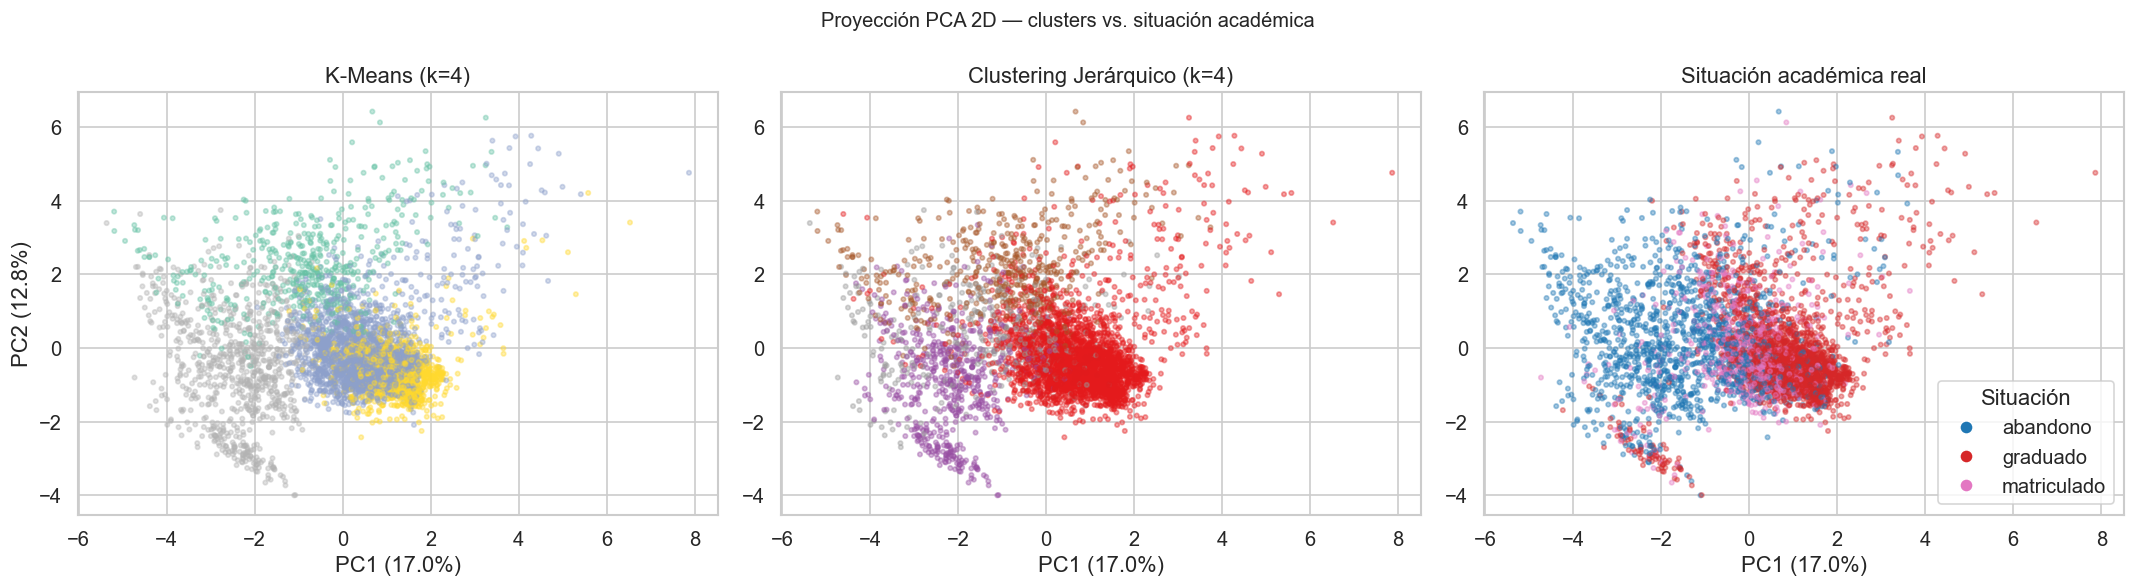

In [19]:
le_obj       = LabelEncoder()
objetivo_enc = le_obj.fit_transform(objetivo)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=cluster_labels,
                cmap="Set2", alpha=0.4, s=7)
axes[0].set_title(f"K-Means (k={k_optimo})")
axes[0].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")

# Jerárquico
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=labels_hc,
                cmap="Set1", alpha=0.4, s=7)
axes[1].set_title(f"Clustering Jerárquico (k={k_optimo})")
axes[1].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")

# Situación académica real
colors_obj = [plt.cm.tab10(i / 3) for i in objetivo_enc]
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=colors_obj, alpha=0.4, s=7)
handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=plt.cm.tab10(i / 3), markersize=8, label=cls)
    for i, cls in enumerate(le_obj.classes_)
]
axes[2].legend(handles=handles, title="Situación")
axes[2].set_title("Situación académica real")
axes[2].set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")

plt.suptitle("Proyección PCA 2D — clusters vs. situación académica", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/03_pca_clusters_vs_objetivo.png", bbox_inches="tight")
plt.show()

## 8. Estabilidad de los clusters (ARI)

In [20]:
labels_s0  = KMeans(n_clusters=k_optimo, random_state=0,  n_init=10).fit_predict(X_prep)
labels_s99 = KMeans(n_clusters=k_optimo, random_state=99, n_init=10).fit_predict(X_prep)
labels_s42 = KMeans(n_clusters=k_optimo, random_state=42, n_init=10).fit_predict(X_prep)

print("ARI entre distintas semillas de K-Means:")
print(f"  semilla 0  vs 99 : {adjusted_rand_score(labels_s0,  labels_s99):.4f}")
print(f"  semilla 0  vs 42 : {adjusted_rand_score(labels_s0,  labels_s42):.4f}")
print(f"  semilla 99 vs 42 : {adjusted_rand_score(labels_s99, labels_s42):.4f}")
print(f"\nARI K-Means vs Jerárquico: {adjusted_rand_score(cluster_labels, labels_hc):.4f}")
print("""
ARI > 0.8  → alta estabilidad.
ARI 0.5–0.8 → estructura moderada.
ARI < 0.5  → clusters sensibles al método/semilla.
""")

ARI entre distintas semillas de K-Means:
  semilla 0  vs 99 : 0.8423
  semilla 0  vs 42 : 0.4859
  semilla 99 vs 42 : 0.4283

ARI K-Means vs Jerárquico: 0.4416

ARI > 0.8  → alta estabilidad.
ARI 0.5–0.8 → estructura moderada.
ARI < 0.5  → clusters sensibles al método/semilla.



## 9. Relación clusters vs. situación académica

In [21]:
cross = pd.crosstab(df["cluster"], df["objetivo"], normalize="index").round(3) * 100
print("Distribución de situación académica por cluster (%):")
print(cross.to_string())
cross.to_csv("../outputs/03_clusters_vs_objetivo.csv")

Distribución de situación académica por cluster (%):
objetivo  abandono  graduado  matriculado
cluster                                  
0             42.1      42.9         15.1
1             21.3      54.1         24.6
2              9.2      79.5         11.3
3             80.0       9.7         10.4


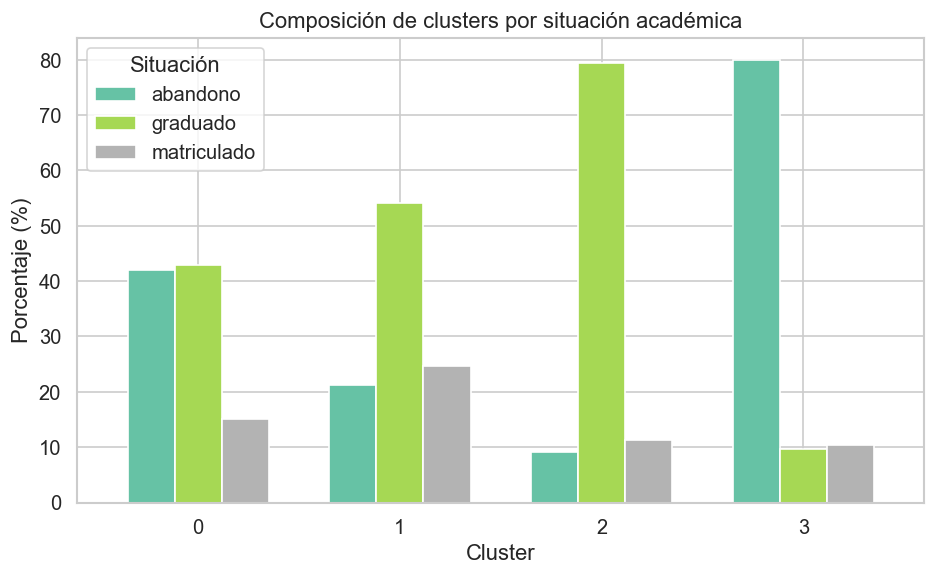

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
cross.plot(kind="bar", ax=ax, edgecolor="white", width=0.7, colormap="Set2")
ax.set_title("Composición de clusters por situación académica")
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Cluster")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Situación")
plt.tight_layout()
plt.savefig("../outputs/03_clusters_objetivo_barras.png", bbox_inches="tight")
plt.show()

## 10. Guardar etiquetas y conclusiones

In [23]:
df[["cluster", "objetivo"]].to_csv("../outputs/03_etiquetas_cluster.csv")
print("Etiquetas guardadas en outputs/03_etiquetas_cluster.csv")

Etiquetas guardadas en outputs/03_etiquetas_cluster.csv


## Conclusiones

- PCA muestra que los **2–4 primeros componentes** capturan la mayor parte de la varianza. La dirección PC1 está dominada por el rendimiento del 1.er semestre; PC2 por el perfil de entrada.
- K-Means identifica perfiles diferenciados que **se solapan parcialmente** con la variable objetivo: los clusters no recuperan exactamente las 3 clases, pero sí detectan patrones de riesgo y éxito.
- Los clusters con mayor tasa de Abandono presentan sistemáticamente **nota de acceso baja**, **pocas asignaturas aprobadas en 1.er semestre** y **problemas de pago** — variables sobre las que una institución podría intervenir.
- La estabilidad (ARI entre semillas) valida la solidez de los clusters encontrados.
- Ejemplo de perfiles orientativos (ajustar tras ver el heatmap):

| Cluster | Nombre tentativo | Rasgos principales |
|---------|-----------------|--------------------|
| Alto rendimiento | Nota alta, muchas aprobadas, al día de pago. Alta proporción Graduado. |
| En riesgo | Nota baja, pocas aprobadas, deudor. Alta proporción Abandono. |
| Intermedio | Perfil mixto. Mezcla de Matriculado y Graduado. |